# 📘 Naive Bayes – Complete Theory

## 1. Introduction
- **Naive Bayes** is a **supervised machine learning algorithm** based on **Bayes’ Theorem**.
- It is called "naive" because it assumes that all features are **independent** of each other, which is rarely true in real-world data.
- Despite this assumption, it works surprisingly well for many practical problems.

---

## 2. Bayes’ Theorem
Bayes’ Theorem provides a way to calculate the probability of a class given some features:



\[
P(Class | Features) = \frac{P(Features | Class) \cdot P(Class)}{P(Features)}
\]



Where:
- \(P(Class | Features)\) → Posterior probability (what we want).
- \(P(Features | Class)\) → Likelihood (probability of features given the class).
- \(P(Class)\) → Prior probability (how common the class is).
- \(P(Features)\) → Evidence (probability of features overall).

---

## 3. How Naive Bayes Works (Step by Step)
1. Calculate prior probabilities for each class.
2. For a new data point, calculate the likelihood of features given each class.
3. Multiply likelihood × prior for each class.
4. Choose the class with the highest posterior probability.

---

## 4. Types of Naive Bayes
| **Type** | **Description** | **Use Case** |
|----------|-----------------|--------------|
| **Gaussian Naive Bayes** | Assumes features follow a normal distribution | Continuous data (e.g., height, weight) |
| **Multinomial Naive Bayes** | Works with discrete counts | Text classification (spam detection, word counts) |
| **Bernoulli Naive Bayes** | Works with binary features | Document classification (word present/absent) |

---

## 5. Advantages
- Simple and fast.
- Works well with small datasets.
- Effective for text classification problems.
- Requires less training data.
- Can handle high-dimensional data.

---

## 6. Limitations
- Assumes independence between features (often unrealistic).
- If a feature value never occurs in training data for a class, probability becomes zero (can be fixed with **Laplace smoothing**).
- Less accurate when features are highly correlated.

---

## 7. Applications
- Spam email detection.
- Sentiment analysis.
- Document classification.
- Medical diagnosis.
- Recommendation systems.

---

## 8. Example Intuition
- Suppose you want to classify whether a message is **spam** or **not spam**.
- Naive Bayes calculates probabilities based on words:
  - If "free" and "win" appear often in spam emails, the probability of spam increases.
- Even though words are not truly independent, the model still performs well.

---

## 9. Summary
- **Naive Bayes = Probabilistic classifier based on Bayes’ Theorem.**
- Assumes features are independent (naive assumption).
- Variants: Gaussian, Multinomial, Bernoulli.
- Best suited for **text classification** and problems with categorical data.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv("cancer1.csv")
df.head(2)

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,2,130,250,0,1,187,0,3.5,0,0,2,1


In [5]:
df.tail()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
574,57,0,140,241,0,1,123,1,0.2,1,0,3,0
575,45,3,110,264,0,1,132,0,1.2,1,0,3,0
576,68,0,144,193,1,1,141,0,3.4,1,2,3,0
577,57,0,130,131,0,1,115,1,1.2,1,1,3,0
578,57,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
df.describe()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,55.431779,0.734024,132.946459,248.563040,0.153713,0.490501,144.620035,0.433506,1.299827,1.288428,0.937824,2.423143,0.284974
std,8.625429,1.002626,18.136609,50.683878,0.360986,0.533802,23.324045,0.495987,1.257139,0.601084,1.053715,0.656785,0.451792
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,120.000000,212.000000,0.000000,0.000000,129.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,57.000000,0.000000,130.000000,245.000000,0.000000,0.000000,146.000000,0.000000,1.000000,1.000000,1.000000,3.000000,0.000000
75%,61.500000,2.000000,140.000000,282.000000,0.000000,1.000000,162.000000,1.000000,2.000000,2.000000,2.000000,3.000000,1.000000
max,77.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.shape

(579, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       579 non-null    int64  
 1   cp        579 non-null    int64  
 2   trestbps  579 non-null    int64  
 3   chol      579 non-null    int64  
 4   fbs       579 non-null    int64  
 5   restecg   579 non-null    int64  
 6   thalach   579 non-null    int64  
 7   exang     579 non-null    int64  
 8   oldpeak   579 non-null    float64
 9   slope     579 non-null    int64  
 10  ca        579 non-null    int64  
 11  thal      579 non-null    int64  
 12  target    579 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 58.9 KB


In [9]:
df.columns

Index(['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [10]:
df.isna().sum()

age         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
df.target.value_counts()

target
0    414
1    165
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

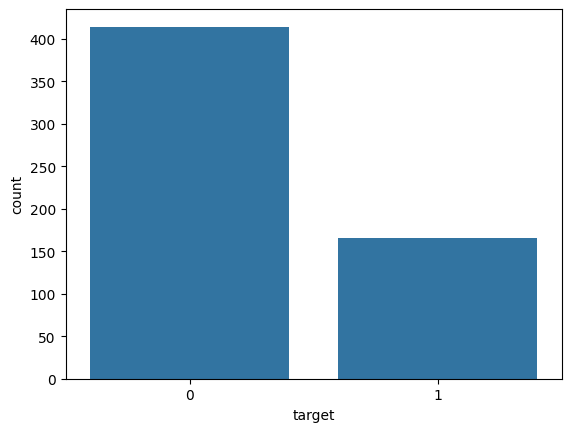

In [12]:
sns.countplot(x='target',data = df)

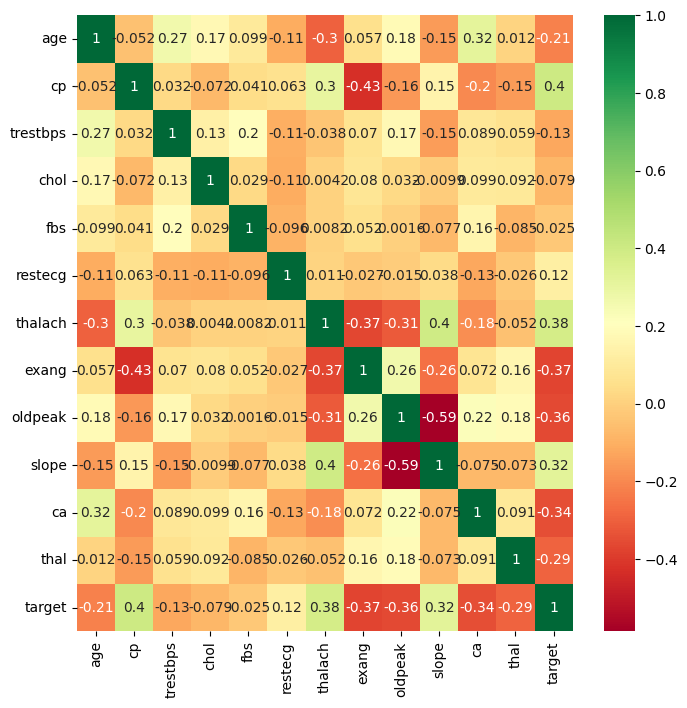

In [18]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.show()

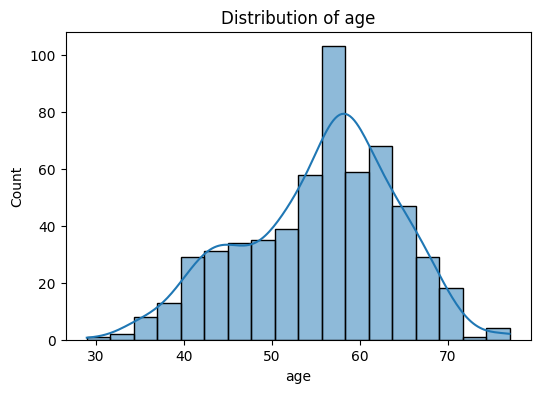

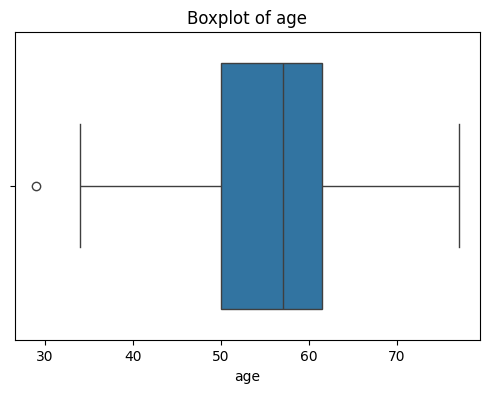

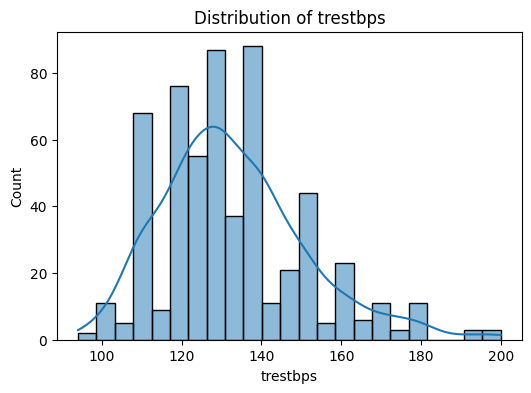

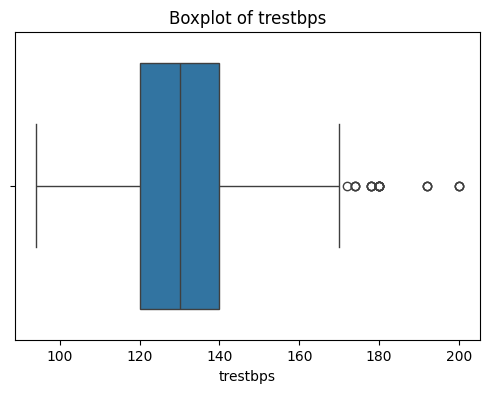

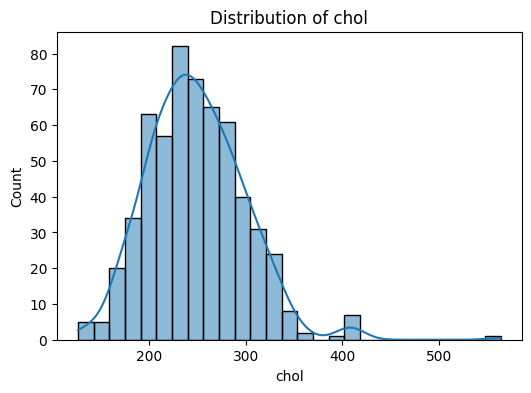

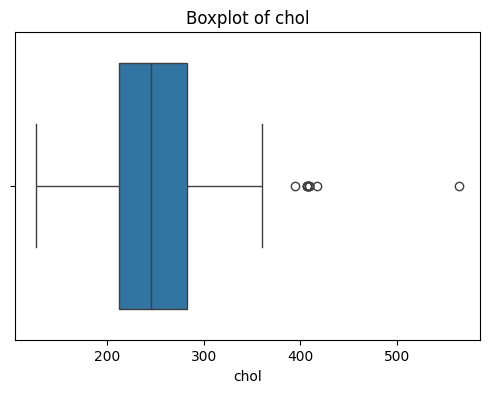

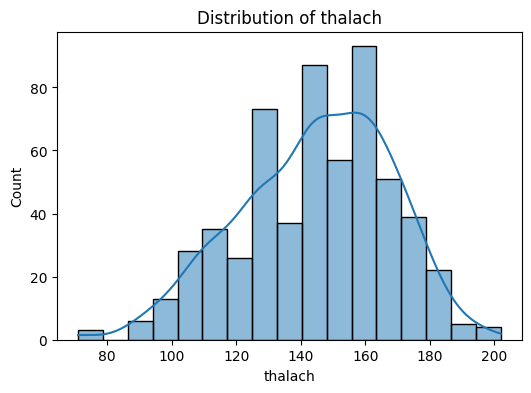

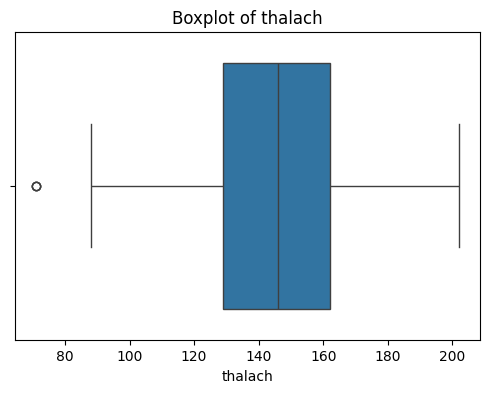

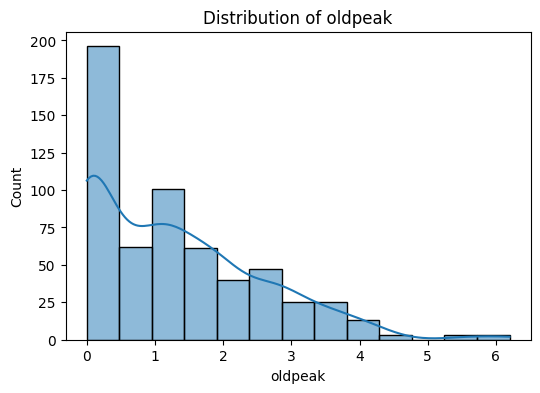

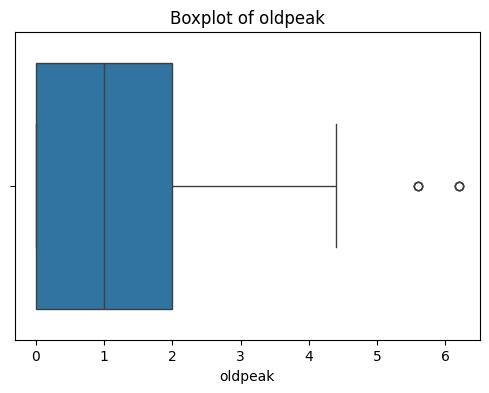

In [15]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [19]:
df.columns

Index(['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [20]:
X = df[['age', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
       'oldpeak', 'slope', 'ca', 'thal']]
y = df['target']

In [21]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

## Bernoulli Naive Bayes

In [25]:
from sklearn.naive_bayes import BernoulliNB
gnb = BernoulliNB()
gnb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [26]:
gnb.score(X_test,y_test)

0.8189655172413793

In [27]:
gnb.predict(X_test)

array([0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0])

In [28]:
y_predict = gnb.predict(X_test)

In [30]:
from sklearn.metrics import classification_report , confusion_matrix

print("Classification Report")
clf = classification_report(y_test,y_predict)
print(clf)

print("-"*40)

print("Confusion Matrix")
cm = confusion_matrix(y_test,y_predict)
print(cm)

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88        85
           1       0.67      0.65      0.66        31

    accuracy                           0.82       116
   macro avg       0.77      0.76      0.77       116
weighted avg       0.82      0.82      0.82       116

----------------------------------------
Confusion Matrix
[[75 10]
 [11 20]]


<Axes: >

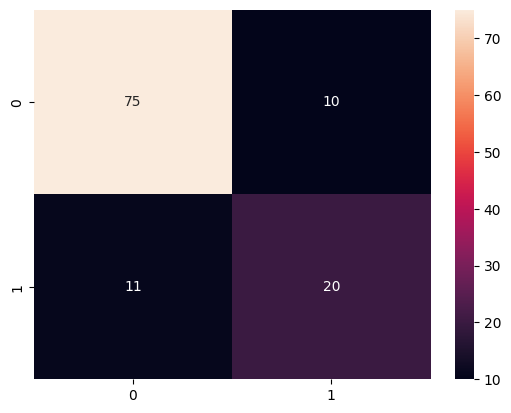

In [31]:
sns.heatmap(cm,annot=True)